<h1>Decision Tree Classifiers</h1>

<h2>What are Decision Trees?</h2>

<i>"Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features."</i>
- <a href = https://scikit-learn.org/stable/modules/tree.html#tree>scikit-learn user guide</a>

<b>Decision Tree</b> algorithms are one of the easiest Machine Learning algorithms to understand and visualise:

<img src = 'https://miro.medium.com/v2/resize:fit:1400/1*3buWChRHuasrTI2iJfCCnA.png' alt = 'Visualisation of a Decision Tree'>

The Tree starts at a <b><font color = 'yellow'>Root Node</font></b>, and then branches off into several <b><font color = 'blue'>Decision Nodes</font></b>. The results can be found at the <b><font color = 'red'>Leaf Nodes</font></b> of the tree.
<br>
The <b><font color = 'blue'>Decision Nodes</font></b> represent attributes by which the algorithm will differentiate between data points.

<h2>Pros and Cons of Decision Tree Classifiers</h2>

<h3>Pros:</h3>
<ol>
    <li>Easy to understand, interpret and visualise compared to other types of Machine Learning algorithms.</li>
    <li>Usually able to handle both numerical as well as categorical data. However, scikit-learn's algorithm only supports numerical data.</li>
</ol>

<h3>Cons:</h3>
<ol>
    <li>Prone to <i>overfitting</i>, which happens when the Tree stays too close to the training set and does not generalise the data well. Overfitted Trees are no longer capable of making accurate predictions with data outside of the training set.</li>
    <li>Small fluctuations in the data can result in a different Tree being generated, leading to a potentially suboptimal representation of the data.</li>
</ol>

<h2>Implementing a Decision Tree Classifier</h2>
This is an exemplary implementation of a Decision Tree Classifier using the <i>Iris</i> dataset, which is a standard dataset that's already included in scikit-learn.

<h3>1. Importing the algorithm and the data</h3>

First, here are some handy libraries that you (might) need.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris #the Iris dataset we will be working with here

from sklearn import tree #the Decision Tree algorithm
from sklearn.model_selection import train_test_split #a function to automatically divide your data into training and testing sets
from sklearn.metrics import accuracy_score #a function to calculate the accuracy of the algorithm

Now, we define the Decision Tree and load the <i>Iris</i> dataset. We also split up the data into the <font color = 'red'>input (X)</font> and <font color = 'blue'>output (y)</font> sets as well as dividing it into <font color = 'green'>training</font> and <font color = 'orange'>testing</font> sets.

In [2]:
dtClass = tree.DecisionTreeClassifier()
iris = load_iris()
X, y = iris.data, iris.target #Assigning input and output sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) #data is split into train and test set and defining test size

About 80% of your dataset should be used for <font color = 'green'>training</font>, which is why we set the <font color = 'orange'>test size</font> to 0.2.

<h3>2. Using the Classifier</h3>

To be able to classify data, the Decision Tree needs to be <font color = 'green'>trained</font> first, which can be done using the function <i>fit()</i>. <br>
Then, the Tree can make predictions using the <i>predict()</i> function. The first set the model will predict is the <font color = 'orange'>testing</font> et to estimate the model's accuracy. Afterwards, you can pass any additional data you have using this function.

In [3]:
dtClass.fit(X_train, y_train) #Passing the training set
pred_dt = dtClass.predict(X_test) #Passing the input set for testing

<h3>3. Visualising the Decision Tree</h3>

Using the <i>plot_tree</i> function, the Decision Tree can be visualised to see how it categorised features. This visualisation can be customised with <i>Matplotlib</i>.

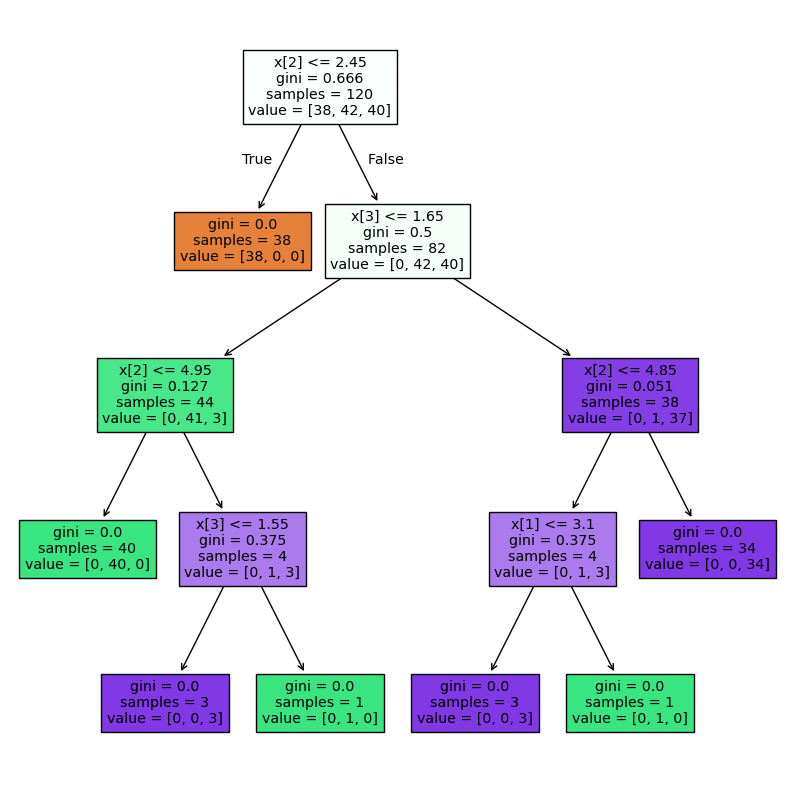

In [4]:
plt.figure(figsize = (10, 10)) #Setting width and height of the visual
tree.plot_tree(dtClass, filled = True)
plt.show()

<h3>4. Calculating Accuracy</h3>

To see how well the Decision Tree algorithm is doing, we can calculate the accuracy, both for the <font color = 'orange'>testing</font> as well as the <font color = 'green'>training</font> set.

In [5]:
score_dt = accuracy_score(y_test, pred_dt) #calculating the accuracy for the testing set
print('Testing Accuracy:', score_dt)

train_pred_dt = dtClass.predict(X_train) #letting the Classifier make predictions on the training data and calculating accuracy
print('Training Accuracy:', accuracy_score(y_train, train_pred_dt))

Testing Accuracy: 0.9333333333333333
Training Accuracy: 1.0


The <font color = 'green'>training accuracy</font> in this case should be close to 100%, which means that the model has accurately learned the patterns within the <font color = 'green'>training</font> data, so when given the same data it was trained on, every prediction the model makes is correct.<br>
<font color = 'orange'>Testing accuracy</font> is usually lower, since this is new data for the model. However, it should not be too far off from the <font color = 'green'>training accuracy</font>. A large discrepancy between the two indicates overfitting.

<h3>5. Preventing overfitting</h3>
One way to prevent overfitting on larger data sets is to limit the <b>maximum depth</b> of the Decision Tree, by calling <i>max_depth</i> when initialising. Doing so also reduces computational load and may increase the model's efficiency while retaining similar performance.

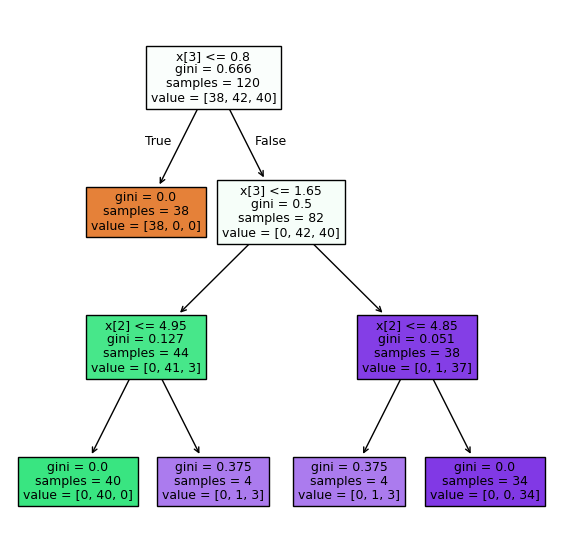

In [6]:
dtLimit = tree.DecisionTreeClassifier(max_depth = 3) #initialising a decision tree with a maximum depth of 3
dtLimit.fit(X_train, y_train)

#Visualising the tree:
plt.figure(figsize = (7, 7))
tree.plot_tree(dtLimit, filled = True)
plt.show()

In [7]:
pred_dtlimit = dtLimit.predict(X_test)
print('Testing Accuracy: ', accuracy_score(y_test, pred_dtlimit))

train_pred_dtlimit = dtLimit.predict(X_train)
print('Training Accuracy: ', accuracy_score(y_train, train_pred_dtlimit))

Testing Accuracy:  0.9666666666666667
Training Accuracy:  0.9833333333333333


<h2>Further Information:</h2>
For more information on Decision Tree classifiers, the scikit-learn documentation and user guide are valuable resources.
<ol>
    <li><a href = 'https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html'>scikit-learn Documentation</a>: List of all parameters and additional functionality of Decision Trees.</li>
    <li><a href = 'https://scikit-learn.org/stable/modules/tree.html'>scikit-learn User Guide</a>: More information about Decision Trees and how to implement them.</li>
</ol>